In [37]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [38]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)
# cache_dir indicates where to download data. I specified . which means current directory
# untar true will unzip it

In [39]:
data_dir

'./datasets/flower_photos'

In [40]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

PosixPath('datasets/flower_photos')

In [41]:
len(list(data_dir.glob('**/*.jpg')))

3670

In [42]:
if (data_dir / 'flower_photos').exists():
    data_dir = data_dir / 'flower_photos'

In [43]:
roses = list(data_dir.glob('roses/*'))

In [44]:
roses[:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/494803274_f84f21d53a.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/7251352826_69b62cba2c_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/3873271620_1d9d314f01_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/7376473742_532364cee5_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/9164924345_6b63637acf.jpg')]

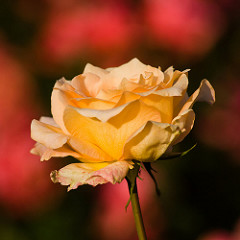

In [45]:
PIL.Image.open(str(roses[1]))

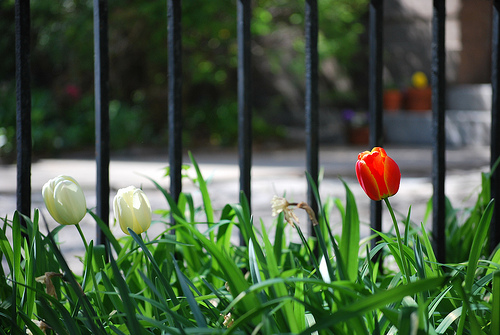

In [46]:
tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[2]))

In [47]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

In [48]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

array([[[  1,  20,  25],
        [  0,  19,  24],
        [  0,  18,  23],
        ...,
        [ 10,  13,  44],
        [ 11,  15,  44],
        [ 11,  15,  44]],

       [[  0,  19,  24],
        [  0,  18,  23],
        [  0,  18,  23],
        ...,
        [ 10,  13,  44],
        [ 10,  14,  43],
        [ 10,  14,  43]],

       [[  0,  19,  22],
        [  0,  18,  23],
        [  0,  18,  23],
        ...,
        [  9,  13,  42],
        [  9,  13,  42],
        [  9,  13,  42]],

       ...,

       [[  2,  41,  43],
        [  3,  42,  44],
        [  2,  43,  45],
        ...,
        [ 35,  47, 117],
        [ 37,  51, 123],
        [ 41,  55, 127]],

       [[  1,  42,  44],
        [  1,  42,  44],
        [  2,  43,  45],
        ...,
        [ 35,  48, 122],
        [ 40,  53, 127],
        [ 43,  56, 132]],

       [[  0,  41,  43],
        [  1,  42,  44],
        [  1,  42,  44],
        ...,
        [ 39,  52, 128],
        [ 44,  57, 133],
        [ 47,  61, 137]]], dtype=uint8)
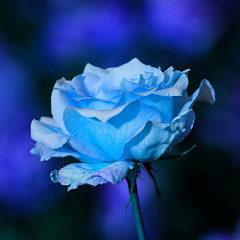

In [49]:
img = cv2.imread(str(flowers_images_dict['roses'][1]))
img

In [50]:
cv2.resize(img,(180,180)).shape

(180, 180, 3)

In [51]:
X, y = [] , []
for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(180,180))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [52]:
X = np.array(X)
y = np.array(y)

In [53]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [54]:
len(X_train)

2752

In [55]:
len(X_test)

918

array([[[ 37,  54,  26],
        [ 44,  54,  29],
        [ 53,  57,  36],
        ...,
        [ 47,  64,  63],
        [ 39,  65,  69],
        [ 46,  69,  64]],

       [[ 46,  47,  34],
        [ 49,  55,  38],
        [ 51,  58,  41],
        ...,
        [ 51,  71,  70],
        [ 42,  74,  79],
        [ 43,  70,  66]],

       [[ 45,  50,  31],
        [ 42,  51,  29],
        [ 49,  58,  34],
        ...,
        [ 58,  73,  80],
        [ 49,  73,  83],
        [ 52,  74,  74]],

       ...,

       [[239, 235, 205],
        [254, 245, 212],
        [253, 244, 206],
        ...,
        [100, 101, 163],
        [ 95,  96, 152],
        [ 94,  92, 143]],

       [[231, 217, 197],
        [255, 237, 211],
        [254, 240, 209],
        ...,
        [ 98,  81, 140],
        [101,  78, 137],
        [110,  82, 141]],

       [[214, 196, 180],
        [230, 219, 191],
        [249, 230, 198],
        ...,
        [ 95,  68, 137],
        [ 96,  76, 139],
        [104,  87, 145]]], dtype=uint8)
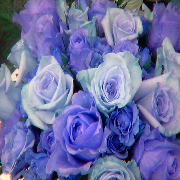

In [56]:
X[0]

In [57]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [69]:
num_classes = 5

model = Sequential([
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.fit(X_train_scaled, y_train, epochs=20)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.4073 - loss: 1.3741
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5890 - loss: 1.0537
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.6744 - loss: 0.8514
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.7762 - loss: 0.6250
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8521 - loss: 0.4144
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9193 - loss: 0.2364
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9655 - loss: 0.1224
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9778 - loss: 0.0769
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9840 - loss: 0.0568
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9880 - loss: 0.0415
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9924 - loss: 0.0305
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy:

In [59]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.6329 - loss: 3.4683


[3.468262195587158, 0.6328976154327393]

In [60]:
predictions = model.predict(X_test_scaled)
predictions

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


array([[  2.9476454 ,   4.9735527 ,   0.40316784, -14.8422    ,
         10.67512   ],
       [ 13.193652  ,  -2.033511  ,  -8.817338  , -24.473654  ,
          2.0682821 ],
       [ -7.013943  ,   4.123513  ,  10.347752  ,  -7.4981375 ,
          1.3891517 ],
       ...,
       [ -4.5043535 ,  -0.7826606 ,  -1.4942724 ,   8.809883  ,
         -2.174745  ],
       [ 10.900502  ,   4.027426  ,   2.885809  ,  -7.2290893 ,
         -8.757944  ],
       [-14.994652  , -24.411226  ,  11.890535  ,  36.702145  ,
         10.391011  ]], dtype=float32)

In [61]:
score = tf.nn.softmax(predictions[0])
score

<tf.Tensor: shape=(5,), dtype=float32, numpy=
array([4.3888035e-04, 3.3280251e-03, 3.4458280e-05, 8.2473490e-12,
       9.9619859e-01], dtype=float32)>

In [62]:
np.argmax(score)

np.int64(4)

In [63]:
y_test[0]

np.int64(1)

In [66]:
# Define the image dimensions
img_height = 180
img_width = 180
batch_size = 32

# Now your data_augmentation block will work!
data_augmentation = keras.Sequential([
  layers.RandomFlip("horizontal", input_shape=(img_height, img_width, 3)),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


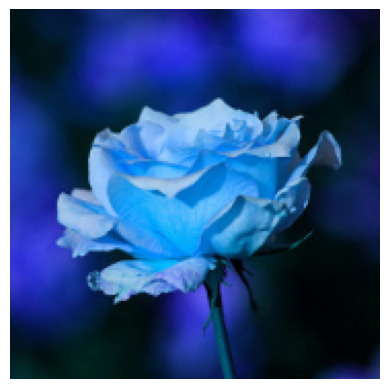

In [72]:
plt.axis('off')
plt.imshow(X[1])

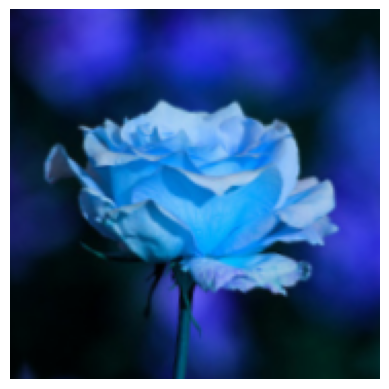

In [73]:
plt.axis('off')
plt.imshow(data_augmentation(X)[1].numpy().astype("uint8"))

In [76]:
num_classes = 5

model = Sequential([
  data_augmentation,
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.fit(X_train_scaled, y_train, epochs=30)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.4048 - loss: 1.3618
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5694 - loss: 1.0744
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.6370 - loss: 0.9500
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.6701 - loss: 0.8587
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.6831 - loss: 0.7922
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.6969 - loss: 0.7637
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.7289 - loss: 0.7131
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.7307 - loss: 0.6942
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.7584 - loss: 0.6408
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.7580 - loss: 0.6414
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.7602 - loss: 0.6177
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy:

In [77]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7353 - loss: 0.9090


[0.9090226292610168, 0.7352941036224365]